# 📊 Mini-Projeto Avaliativo

### Aluno: Orlando Vieira de Castro Junior
---

### Contexto

Trata-se da Análise Exploratória de Dados (EDA) aplicada ao varejo para aprender como transformar dados brutos em informações úteis.

A base “Varejo” contém registros reais de compras (datas, clientes, produtos, categorias e valores). Aprender a verificar qualidade, limpar e sumarizar esses dados é uma habilidade prática essencial para quem trabalha com BI e Visualização de Dados.

O objetivo deste mini-projeto é colocar em prática as tarefas comuns no trabalho: identificar problemas nos dados (valores nulos, tipos incorretos, duplicados), tratar esses problemas com ferramentas como pandas e gerar estatísticas  simples e funções de agrupamento, para responder perguntas operacionais (quem compra mais, quais categorias vendem mais, como variam as vendas ao longo do tempo).

O objetivo educacional é, ao final, apresentar uma base para análises mais avançadas ou para alimentar um dashboard: entender os dados, limpá-los, extrair estatísticas descritivas e comunicar os principais insights de forma objetiva.

### Desafio

Entregar um script em Python que realize uma Análise Exploratória da base Varejo seguindo etapas claras, documentadas e reproduzíveis.

**Etapas obrigatórias:**

* Carregar a base Varejo.csv com pandas e mostrar: número de registros, colunas e tipos de dados.
* Verificar e reportar ao menos dois problemas básicos: valores nulos por coluna, duplicatas e possíveis inconsistências (ex.: datas inválidas ou categorias vazias).
* Fazer as três etapas de limpeza mínima necessária: remover ou imputar nulos (explique a escolha), eliminar duplicatas relevantes e ajustar tipos de dados (ex.: converter coluna DATA para datetime).
* Gerar estatísticas descritivas básicas para coluna de número de filhos do cliente (média; mediana; desvio padrão; moda; máximo; mínimo; e contagem).
* Explorar padrões de agrupamento com pelo menos dois agrupamentos (por exemplo: gênero com mais vendas, compras), usando groupby() ou pivot_table().
* Produzir um pequeno bloco de conclusões (3–6 tópicos) com os principais insights obtidos e possíveis problemas remanescentes na base.

**Requisitos técnicos mínimos:**

* O script deve ser executável em VsCode ou Google Colab (arquivo .py).
* Usar pandas; outras bibliotecas são opcionais (NumPy, Matplotlib, Seaborn).   

Base de dados (varejo) sugerida no Kaggle: https://www.kaggle.com/datasets/namespaiva/base-varejo/data

### ETAPAS DA TAREFA

### PASSO 1 - Carregar a base Varejo.csv com pandas e mostrar: número de registros, colunas e tipos de dados.


In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# URL da planilha que usamos nesta aula
URL = (
    "https://raw.githubusercontent.com/"
    "cfneves/turma-visualizacao-de-dados/"
    "master/alunos/orlando_castro/modulo-01/mini-projeto/orlando_castro/dataset/Varejo.csv"
)

df = pd.read_csv(
    URL,
    sep=";",                # separador de campos
    encoding="cp1252",      # encoding para lidar com caracteres acentuados no Windows
    decimal=",")           # separador decimal

print("✅Dados carregados com sucesso!")
print("=" * 40)
print(f' Número de linhas: {df.shape[0]}')
print(f' Número de colunas: {df.shape[1]}')


✅Dados carregados com sucesso!
 Número de linhas: 830000
 Número de colunas: 14


### Passo 2 - Fazer uma análise preliminar dos dados

| Método | O que mostra |
|---|---|
| `head(10)` | As 10 primeiras linhas |
| `tail()` | As 5 últimas linhas |
| `columns` | Nome de todas as colunas |
| `info()` | Tipo de dado de cada coluna e se há valores nulos |
| `describe()` | Estatísticas das colunas numéricas (média, mín, máx...) |

In [2]:
# Mostrar as primeiras e últimas linhas do DataFrame
print(df.head(10))   # 10 primeiras linhas
print(df.tail())     # últimas 5 linhas

         DATA  CO_ID  CL_ID CL_GENERO  CL_EC  CL_FHL CL_SEG  PR_ID     PR_CAT  \
0  01/02/2019   1000    534         M      4       1      C     67    BEBIDAS   
1  01/02/2019   1000    534         M      4       1      C     70    BEBIDAS   
2  01/02/2019   1000    534         M      4       1      C    178    HIGIENE   
3  01/02/2019   1000    534         M      4       1      C      4  ALIMENTOS   
4  01/02/2019   1000    534         M      4       1      C    175    LIMPEZA   
5  01/02/2019   1000    534         M      4       1      C    187    HIGIENE   
6  01/02/2019   1000    534         M      4       1      C    163  ALIMENTOS   
7  01/02/2019   1000    534         M      4       1      C     11  ALIMENTOS   
8  01/02/2019   1000    534         M      4       1      C     95    LIMPEZA   
9  01/02/2019   1000    534         M      4       1      C    198    BEBIDAS   

                PR_NOME  Unnamed: 10  Unnamed: 11  Unnamed: 12  Unnamed: 13  
0  REFRIGERANTE GUARANA       

In [3]:
# Mostrar os nomes das colunas e o resumo completo do DataFrame
print('Nomes das colunas:')
print('=' * 60)
print(df.columns)    # nomes das colunas
print('\nResumo completo do DataFrame:')
print("=" * 60)
df.info()

Nomes das colunas:
Index(['DATA', 'CO_ID', 'CL_ID', 'CL_GENERO', 'CL_EC', 'CL_FHL', 'CL_SEG',
       'PR_ID', 'PR_CAT', 'PR_NOME', 'Unnamed: 10', 'Unnamed: 11',
       'Unnamed: 12', 'Unnamed: 13'],
      dtype='object')

Resumo completo do DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 830000 entries, 0 to 829999
Data columns (total 14 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   DATA         830000 non-null  object 
 1   CO_ID        830000 non-null  int64  
 2   CL_ID        830000 non-null  int64  
 3   CL_GENERO    830000 non-null  object 
 4   CL_EC        830000 non-null  int64  
 5   CL_FHL       830000 non-null  int64  
 6   CL_SEG       830000 non-null  object 
 7   PR_ID        830000 non-null  int64  
 8   PR_CAT       830000 non-null  object 
 9   PR_NOME      830000 non-null  object 
 10  Unnamed: 10  0 non-null       float64
 11  Unnamed: 11  0 non-null       float64
 12  Unnamed: 12  0 non-null       

In [4]:
# Mostrar as estatísticas numéricas do DataFrame
print('\nEstatísticas numéricas:')
print('=' * 60)
print(df.describe()) # estatísticas numéricas


Estatísticas numéricas:
              CO_ID          CL_ID          CL_EC        CL_FHL  \
count  830000.00000  830000.000000  830000.000000  830000.00000   
mean   460045.08989     499.595204       2.596911       1.14654   
std    265465.24754     287.568253       1.170599       1.41696   
min      1000.00000       1.000000       1.000000       0.00000   
25%    233117.00000     254.000000       2.000000       0.00000   
50%    456517.00000     498.000000       3.000000       0.00000   
75%    690132.00000     746.000000       4.000000       2.00000   
max    919822.00000    1000.000000       5.000000       4.00000   

               PR_ID  Unnamed: 10  Unnamed: 11  Unnamed: 12  Unnamed: 13  
count  830000.000000          0.0          0.0          0.0          0.0  
mean      115.051855          NaN          NaN          NaN          NaN  
std        66.129241          NaN          NaN          NaN          NaN  
min         1.000000          NaN          NaN          NaN          Na

In [5]:
# Valores nulos por coluna
print("\nNúmero de valores nulos por coluna:\n")
print(df.isnull().sum().to_string())  # usando to_string() para mostrar o DataFrame completo no console

# Verificar valores únicos 
print("\nValores únicos por coluna:\n")
for coluna in df.columns:
    print(f"{coluna}: {df[coluna].nunique()} valores únicos")

# Linhas duplicadas
linhas_duplicadas = df.duplicated().sum()
print(f"\nNúmero de linhas duplicadas: {linhas_duplicadas}")


Número de valores nulos por coluna:

DATA                0
CO_ID               0
CL_ID               0
CL_GENERO           0
CL_EC               0
CL_FHL              0
CL_SEG              0
PR_ID               0
PR_CAT              0
PR_NOME             0
Unnamed: 10    830000
Unnamed: 11    830000
Unnamed: 12    830000
Unnamed: 13    830000

Valores únicos por coluna:

DATA: 333 valores únicos
CO_ID: 18471 valores únicos
CL_ID: 1000 valores únicos
CL_GENERO: 2 valores únicos
CL_EC: 5 valores únicos
CL_FHL: 5 valores únicos
CL_SEG: 3 valores únicos
PR_ID: 229 valores únicos
PR_CAT: 7 valores únicos
PR_NOME: 118 valores únicos
Unnamed: 10: 0 valores únicos
Unnamed: 11: 0 valores únicos
Unnamed: 12: 0 valores únicos
Unnamed: 13: 0 valores únicos

Número de linhas duplicadas: 96553


### Problemas encontrados na base

A verificação preliminar da base de dados indicou os seguintes pontos a serem corrigidos:

- A coluna `DATA` precisa ser convertida para tipo datetime válido;
- As colunas `Unnamed: 10`, `Unnamed: 11`, `Unnamed: 12` e `Unnamed: 13` não possuem dados;
- A base possui 96.553 linhas duplicadas;
- A coluna `PR_CAT` possui valores `#N/D` foi substituído por `OUTROS`


### Passo 3 - Fazer limpeza e tratamento dos dados

Nesta estapa, realizaremos a limpeza dos dados com vistas a eliminar os problemas encontrados no passo anterior.

In [6]:
# Aqui fazemos a limpeza dos dados, removendo as linhas duplicadas
df = df.drop_duplicates()
print(f"\nNúmero de linhas após remover duplicatas: {df.shape[0]}")

# Eliminando as colunas que estão vazias (com 100% de valores nulos)
# Neste caso, temos as colunas `Unnamed: 10`, `Unnamed: 11`, `Unnamed: 12` e `Unnamed: 13`
colunas_vazias = df.columns[df.isnull().all()]
print(f"\nColunas vazias (100% nulas): {list(colunas_vazias)}")
df = df.drop(columns=colunas_vazias)
print(f"\nNúmero de colunas após eliminar as vazias: {df.shape[1]}")
print(f"\nNúmero de linhas após eliminar as vazias: {df.shape[0]}")

# Reunindo as categorias '#N/D' da coluna PR_CAT em uma categoria única chamada 'OUTROS'
df["PR_CAT"] = df["PR_CAT"].replace("#N/D", "OUTROS")
print(f"\nNúmero de linhas por categoria de produto (PR_CAT):")
print(df["PR_CAT"].value_counts().to_string())

# Criar coluna 'ESTADO_CIVIL' a partir da coluna 'CL_EC'
mapa_estado_civil = {
    1: "Casado/União Estável",
    2: "Divorciado",
    3: "Separado",
    4: "Solteiro",
    5: "Viúvo"
}
df['ESTADO_CIVIL'] = df['CL_EC'].map(mapa_estado_civil)



Número de linhas após remover duplicatas: 733447

Colunas vazias (100% nulas): ['Unnamed: 10', 'Unnamed: 11', 'Unnamed: 12', 'Unnamed: 13']

Número de colunas após eliminar as vazias: 10

Número de linhas após eliminar as vazias: 733447

Número de linhas por categoria de produto (PR_CAT):
PR_CAT
ALIMENTOS     384197
HIGIENE       137702
LIMPEZA       128632
BEBIDAS        38264
PET            28553
ACESSORIOS     12871
OUTROS          3228


In [7]:
# Exibir estatísticas numéricas novamente para verificar o impacto da limpeza
print('\nEstatísticas numéricas após limpeza:') 
print('=' * 60)
print(df.describe().to_string())  # usando to_string() para mostrar o DataFrame completo no console



Estatísticas numéricas após limpeza:
               CO_ID          CL_ID          CL_EC         CL_FHL          PR_ID
count  733447.000000  733447.000000  733447.000000  733447.000000  733447.000000
mean   459941.034680     499.643996       2.597385       1.146049     115.037337
std    265431.394822     287.561653       1.170130       1.416917      66.124263
min      1000.000000       1.000000       1.000000       0.000000       1.000000
25%    232895.000000     254.000000       2.000000       0.000000      58.000000
50%    456422.000000     498.000000       3.000000       0.000000     115.000000
75%    690100.000000     746.000000       4.000000       2.000000     172.000000
max    919822.000000    1000.000000       5.000000       4.000000     229.000000


In [8]:
# Converter coluna data para o formato datetime
df['DATA'] = pd.to_datetime(
    df['DATA'], 
    errors='coerce',
    format='%d/%m/%Y'
    )

# Verificar existência de datas inválidas após a conversão
datas_invalidas = df['DATA'].isnull().sum()
print(f"\nNúmero de datas inválidas após a conversão: {datas_invalidas}")



Número de datas inválidas após a conversão: 0


### Passo 4 - Gerar estatísticas descritivas básicas para coluna de número de filhos do cliente

Nesta estapa, serão calculadas as estatísticas (média; mediana; desvio padrão; moda; máximo; mínimo; e contagem) para a coluna de número de filhos.

In [9]:
# Estatísticas descritivas para coluna `CL_FHL`
print("\nESTATÍSTICAS DESCRITIVAS PARA A COLUNA 'CL_FHL':\n")
print(df['CL_FHL'].describe().to_string())

# Verificar os valores únicos na coluna `CL_FHL`
print("\nValores únicos de número de filhos:") 
print(df['CL_FHL'].unique())
print("\nContagem de cada valor único da coluna 'CL_FHL':")
print(df['CL_FHL'].value_counts().to_string())
print(f"\nMédia da coluna 'CL_FHL'        : {df['CL_FHL'].mean().round(1)}")
print(f"Mediana da coluna 'CL_FHL'      : {df['CL_FHL'].median()}")
print(f"Desvio padrão da coluna 'CL_FHL': {df['CL_FHL'].std().round(1)}")
print(f"Valor mínimo da coluna 'CL_FHL' : {df['CL_FHL'].min()}")
print(f"Valor máximo da coluna 'CL_FHL' : {df['CL_FHL'].max()}")



ESTATÍSTICAS DESCRITIVAS PARA A COLUNA 'CL_FHL':

count    733447.000000
mean          1.146049
std           1.416917
min           0.000000
25%           0.000000
50%           0.000000
75%           2.000000
max           4.000000

Valores únicos de número de filhos:
[1 2 0 3 4]

Contagem de cada valor único da coluna 'CL_FHL':
CL_FHL
0    384986
2     94168
3     92407
1     90845
4     71041

Média da coluna 'CL_FHL'        : 1.1
Mediana da coluna 'CL_FHL'      : 0.0
Desvio padrão da coluna 'CL_FHL': 1.4
Valor mínimo da coluna 'CL_FHL' : 0
Valor máximo da coluna 'CL_FHL' : 4


### Passo 5 - Padrões de agrupamento

Nesta etapa serão apresentadas as seguintes análises:

- Vendas por gênero 
- Vendas por categoria de produto
- Vendas por segmentação econômica do cliente
- Vendas por estado civil do cliente
- Vendas por categorias de produtos por gênero
- Vendas por categorias de produtos por segmentação econômica do cliente
- Vendas por categorias de produtos por estado civl do cliente

In [10]:
# Quantidade total de vendas por gênero
vendas_por_genero = (
    df.groupby('CL_GENERO')['CO_ID']
    .count()
    .reset_index()
    .rename(columns={'CO_ID': 'Número de Vendas', 'CL_GENERO': 'Gênero'})
    .sort_values(by='Número de Vendas', ascending=False)
    )

print("\nTotal de vendas por gênero:\n")
print(vendas_por_genero.reset_index(drop=True).to_string(formatters={'Número de Vendas': '{:,}'.format}))
print("Total geral de vendas: {}".format(df['CO_ID'].count()))

genero_com_mais_vendas = df.groupby('CL_GENERO')['CO_ID'].sum().idxmax()
if genero_com_mais_vendas == 'F':
    genero_com_mais_vendas = 'Feminino'
elif genero_com_mais_vendas == 'M':
    genero_com_mais_vendas = 'Masculino'
print(f"\nGênero com maior quantidade de vendas: {genero_com_mais_vendas}")


Total de vendas por gênero:

  Gênero Número de Vendas
0      F          382,427
1      M          351,020
Total geral de vendas: 733447

Gênero com maior quantidade de vendas: Feminino


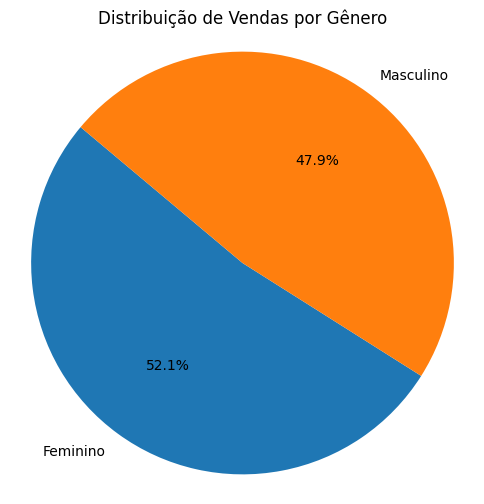

In [11]:
# Exibir um gráfico de pizza para a distribuição de vendas por gênero

# Se genero = 'F', mostrar como 'Feminino'; se genero = 'M', mostrar como 'Masculino'
vendas_por_genero['Gênero'] = vendas_por_genero['Gênero'].map({'F': 'Feminino', 'M': 'Masculino'})

plt.figure(figsize=(6, 6))
plt.pie(vendas_por_genero['Número de Vendas'], 
        labels=vendas_por_genero['Gênero'], 
        autopct='%1.1f%%', 
        startangle=140)
plt.title('Distribuição de Vendas por Gênero')
plt.axis('equal')
plt.show()


In [12]:
# Quantidade total de vendas por categoria de produto
vendas_por_categoria = (
    df.groupby('PR_CAT')['CO_ID']
    .count()
    .reset_index()
    .rename(columns={'CO_ID': 'Número de Vendas', 'PR_CAT': 'Categoria de Produto'})
    .sort_values(by='Número de Vendas', ascending=False)
    )

print("\nTotal de vendas por categoria de produto:\n")
print(vendas_por_categoria.reset_index(drop=True).to_string(formatters={'Número de Vendas': '{:,}'.format}))
print("Total geral de vendas: {}".format(df['CO_ID'].count()))

categoria_com_mais_vendas = df.groupby('PR_CAT')['CO_ID'].sum().idxmax()
print(f"\nCategoria de produto com maior quantidade de vendas: {categoria_com_mais_vendas}")


Total de vendas por categoria de produto:

  Categoria de Produto Número de Vendas
0            ALIMENTOS          384,197
1              HIGIENE          137,702
2              LIMPEZA          128,632
3              BEBIDAS           38,264
4                  PET           28,553
5           ACESSORIOS           12,871
6               OUTROS            3,228
Total geral de vendas: 733447

Categoria de produto com maior quantidade de vendas: ALIMENTOS


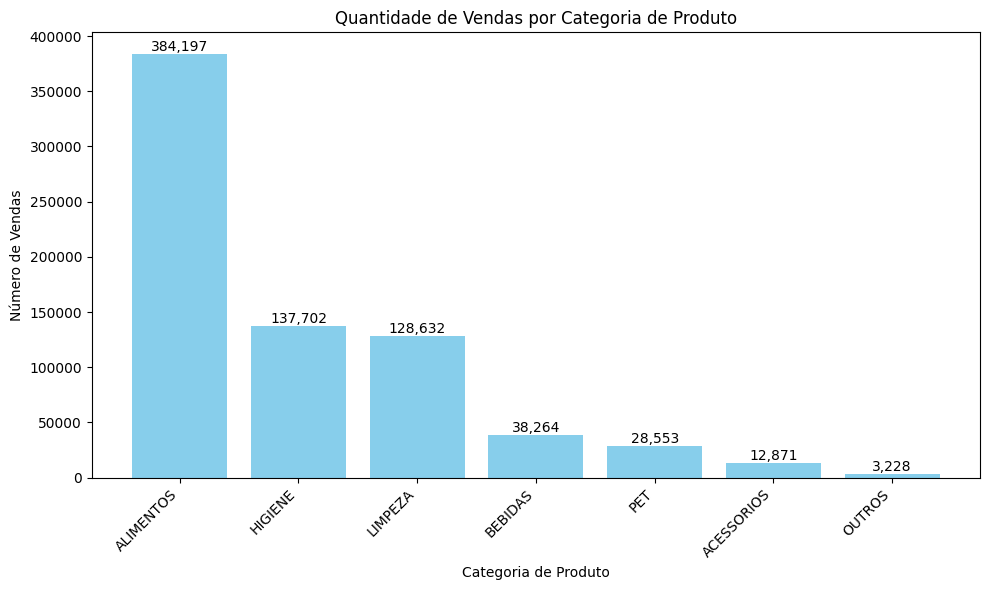

In [13]:
# Apresenta um gráfico de barras para a quantidade de vendas por categoria de produto
plt.figure(figsize=(10, 6)) 
plt.bar(vendas_por_categoria['Categoria de Produto'], vendas_por_categoria['Número de Vendas'], color='skyblue')
plt.xlabel('Categoria de Produto')
plt.ylabel('Número de Vendas')
plt.title('Quantidade de Vendas por Categoria de Produto')
plt.xticks(rotation=45, ha='right')
#insere os valores de vendas no topo de cada barra
for index, value in enumerate(vendas_por_categoria['Número de Vendas']):
    plt.text(index, value, f'{value:,}', ha='center', va='bottom')
plt.tight_layout()
plt.show()

In [14]:
# Quantidade total de vendas por Segmento Econômico de Cliente
vendas_por_segmento_cliente = (
    df.groupby('CL_SEG')['CO_ID']
    .count()
    .reset_index()
    .rename(columns={'CO_ID': 'Número de Vendas', 'CL_SEG': 'Segmento Econômico de Cliente'})
    .sort_values(by='Número de Vendas', ascending=False)
    )

print("\nTotal de vendas por segmento econômico de cliente:\n")
print(vendas_por_segmento_cliente.reset_index(drop=True).to_string(formatters={'Número de Vendas': '{:,}'.format}))
print("Total geral de vendas: {}".format(df['CO_ID'].count()))

segmento_com_mais_vendas = df.groupby('CL_SEG')['CO_ID'].sum().idxmax()
print(f"\nSegmento econômico de cliente com maior quantidade de vendas: {segmento_com_mais_vendas}")


Total de vendas por segmento econômico de cliente:

  Segmento Econômico de Cliente Número de Vendas
0                             B          468,505
1                             C          205,265
2                             A           59,677
Total geral de vendas: 733447

Segmento econômico de cliente com maior quantidade de vendas: B


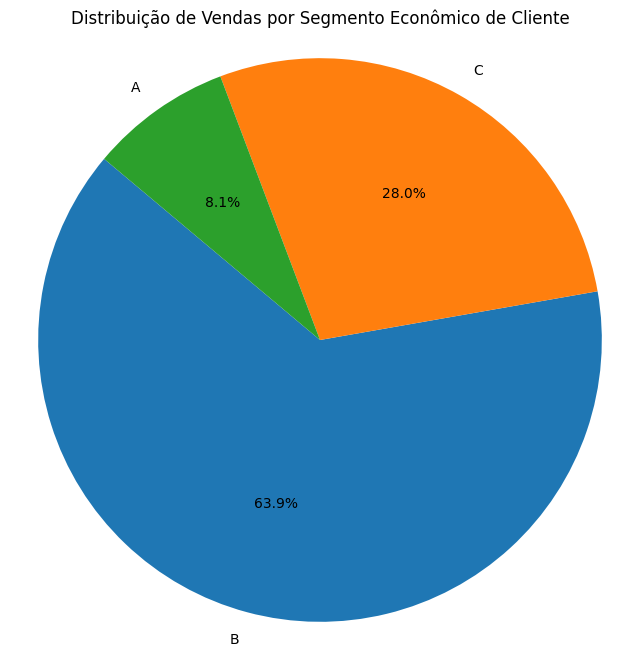

In [15]:
# Apresenta um gráfico de pizza para a distribuição de vendas por segmento econômico de cliente
plt.figure(figsize=(8, 8))
plt.pie(vendas_por_segmento_cliente['Número de Vendas'], 
        labels=vendas_por_segmento_cliente['Segmento Econômico de Cliente'], 
        autopct='%1.1f%%', 
        startangle=140)
plt.title('Distribuição de Vendas por Segmento Econômico de Cliente')
plt.axis('equal')
plt.show()

In [16]:
# Quantidade total de vendas por Estado Civil de Cliente
vendas_por_estado_civil_cliente = (
    df.groupby('ESTADO_CIVIL')['CO_ID']
    .count()
    .reset_index()
    .rename(columns={'CO_ID': 'Número de Vendas', 'ESTADO_CIVIL': 'Estado Civil'})
    .sort_values(by='Número de Vendas', ascending=False)
    )

print("\nTotal de vendas por estado civil:\n")
print(vendas_por_estado_civil_cliente.reset_index(drop=True).to_string(formatters={'Número de Vendas': '{:,}'.format}))
print("Total geral de vendas: {}".format(df['CO_ID'].count()))

estado_civil_com_mais_vendas = df.groupby('ESTADO_CIVIL')['CO_ID'].sum().idxmax()
print(f"\nEstado civil com maior quantidade de vendas: {estado_civil_com_mais_vendas}")


Total de vendas por estado civil:

           Estado Civil Número de Vendas
0              Separado          189,048
1              Solteiro          179,206
2            Divorciado          172,283
3  Casado/União Estável          172,010
4                 Viúvo           20,900
Total geral de vendas: 733447

Estado civil com maior quantidade de vendas: Separado


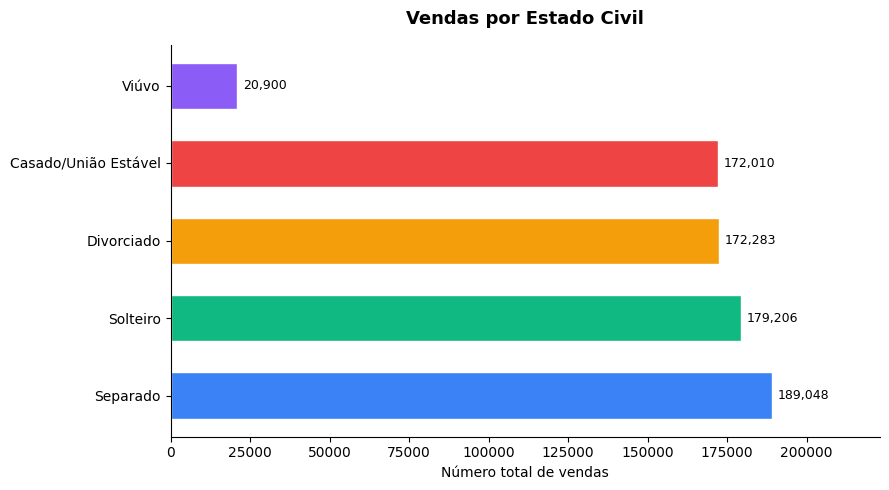

In [17]:
# Apresenta um gráfico de barras horizontais para a quantidade de vendas por estado civil
fig, ax = plt.subplots(figsize=(9, 5))

cores = ['#3b82f6', '#10b981', '#f59e0b', '#ef4444', '#8b5cf6', '#ec4899', '#06b6d4']

bars = ax.barh(
    vendas_por_estado_civil_cliente['Estado Civil'],
    vendas_por_estado_civil_cliente['Número de Vendas'],
    color=cores[:len(vendas_por_estado_civil_cliente)],
    edgecolor='white',
    height=0.6
)

# Anotações de valor em cada barra
max_val = vendas_por_estado_civil_cliente['Número de Vendas'].max()
for i, val in enumerate(vendas_por_estado_civil_cliente['Número de Vendas']):
    ax.text(val + max_val * 0.01, i, f'{val:,}', va='center', fontsize=9)

ax.set_title('Vendas por Estado Civil', fontsize=13, fontweight='bold', pad=15)
ax.set_xlabel('Número total de vendas')
ax.set_xlim(0, max_val * 1.18)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()

In [18]:
# Categorias de Produtos mais comprados por gênero
categorias_mais_compradas_por_genero = (
    df.groupby(['CL_GENERO', 'PR_CAT'])['CO_ID']
    .count()
    .reset_index()
    .rename(columns={'CO_ID': 'Quantidade Total de Vendas', 'CL_GENERO': 'Gênero', 'PR_CAT': 'Categoria'})
    .sort_values(by='Quantidade Total de Vendas', ascending=False)
    )

print("\nCategorias de Produtos mais comprados por gênero (top 10):\n")
print(categorias_mais_compradas_por_genero.head(10).reset_index(drop=True).to_string(formatters={'Quantidade Total de Vendas': '{:,}'.format}))

# Pivot table para analisar a quantidade de vendas por gênero e categoria de produto. 
pivot_vendas_genero_categoria = (
    df.pivot_table(
        index='PR_CAT',
        columns='CL_GENERO',
        values='CO_ID',
        aggfunc='count',
        fill_value=0
    )
    .reset_index()
    .rename(columns={'CL_GENERO': 'Gênero'})
    )

print("\nQuantidade de vendas por gênero e categoria de produto:\n")

print("\nQuantidade de vendas por gênero e categoria de produto:\n")
print(
    pivot_vendas_genero_categoria
    .reset_index(drop=True)
    .to_string(formatters={col: '{:}'
        .format for col in pivot_vendas_genero_categoria.columns if col != 'Gênero'})
    )


Categorias de Produtos mais comprados por gênero (top 10):

  Gênero  Categoria Quantidade Total de Vendas
0      F  ALIMENTOS                    200,274
1      M  ALIMENTOS                    183,923
2      F    HIGIENE                     71,721
3      F    LIMPEZA                     67,328
4      M    HIGIENE                     65,981
5      M    LIMPEZA                     61,304
6      F    BEBIDAS                     19,764
7      M    BEBIDAS                     18,500
8      F        PET                     14,809
9      M        PET                     13,744

Quantidade de vendas por gênero e categoria de produto:


Quantidade de vendas por gênero e categoria de produto:

CL_GENERO      PR_CAT      F      M
0          ACESSORIOS   6839   6032
1           ALIMENTOS 200274 183923
2             BEBIDAS  19764  18500
3             HIGIENE  71721  65981
4             LIMPEZA  67328  61304
5              OUTROS   1692   1536
6                 PET  14809  13744


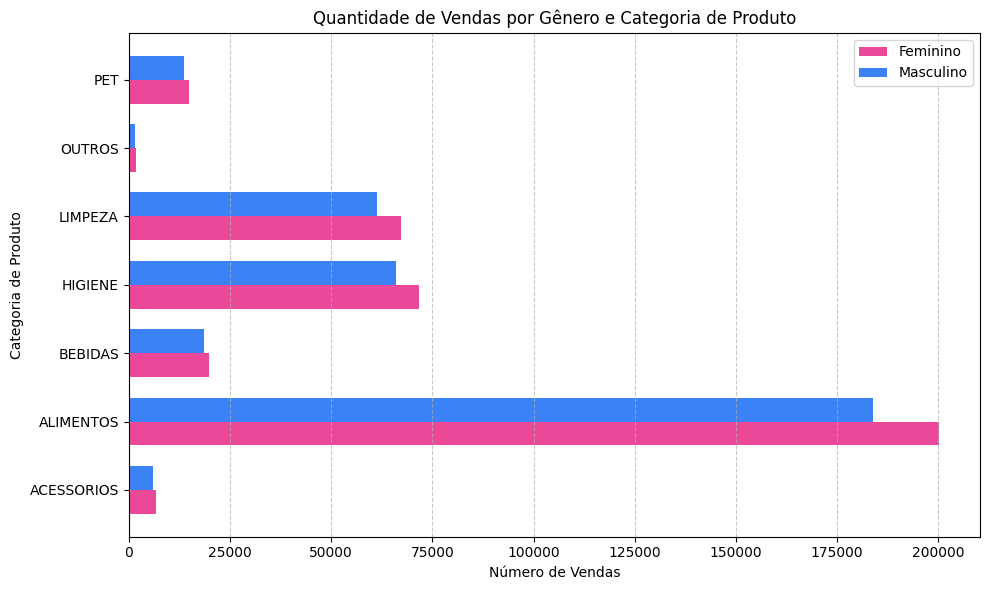

In [19]:
# Apresenta um gráfico de barras horizontais para a quantidade de vendas por gênero e categoria de produto
fig, ax = plt.subplots(figsize=(10, 6)) # Ajustei o tamanho para melhor visualização

# Definindo cores para os gêneros
color_f = '#ec4899' # Um tom de rosa para Feminino
color_m = '#3b82f6' # Um tom de azul para Masculino

# As categorias de produto serão os rótulos do eixo Y
categories = pivot_vendas_genero_categoria['PR_CAT']
# Posições no eixo Y para cada grupo de barras
y_pos = np.arange(len(categories))

# Largura de cada barra individual
bar_height = 0.35

# Plotar as barras para o gênero Feminino
ax.barh(y_pos - bar_height/2, pivot_vendas_genero_categoria['F'], bar_height, label='Feminino', color=color_f)

# Plotar as barras para o gênero Masculino
ax.barh(y_pos + bar_height/2, pivot_vendas_genero_categoria['M'], bar_height, label='Masculino', color=color_m)

# Configurações do gráfico
ax.set_yticks(y_pos) # Define as posições dos ticks no eixo Y
ax.set_yticklabels(categories) # Define os rótulos dos ticks no eixo Y com as categorias
ax.set_xlabel('Número de Vendas')
ax.set_ylabel('Categoria de Produto')
ax.set_title('Quantidade de Vendas por Gênero e Categoria de Produto')
ax.legend() # Mostra a legenda para identificar os gêneros
ax.grid(axis='x', linestyle='--', alpha=0.7) # Adiciona linhas de grade no eixo X para facilitar a leitura

plt.tight_layout() # Ajusta o layout para evitar sobreposição de elementos
plt.show()



In [20]:
# Categorias de Produtos mais comprados por Segmento Econômico de Cliente   
categorias_mais_compradas_por_segmento = (
    df.groupby(['PR_CAT','CL_SEG'])['CO_ID']
    .count()
    .reset_index()
    .rename(columns={'CO_ID': 'Quantidade Total de Vendas', 'CL_SEG': 'Segmento Econômico', 'PR_CAT': 'Categoria'})
    .sort_values(by='Quantidade Total de Vendas', ascending=False)
    )

print("\nCategorias de Produtos mais comprados por segmento econômico (top 10):\n")
print(categorias_mais_compradas_por_segmento.head(10).reset_index(drop=True).to_string(formatters={'Quantidade Total de Vendas': '{:,}'.format}))

# Pivot table para analisar a quantidade de vendas por segmento econômico e categoria de produto
pivot_vendas_segmento_categoria = (
    df.pivot_table(
        index='PR_CAT',
        columns='CL_SEG',
        values='CO_ID',
        aggfunc='count',
        fill_value=0
    )
    .reset_index()
    .rename(columns={'CL_SEG': 'Segmento Econômico'})
    )
print("\nQuantidade de vendas por segmento econômico e categoria de produto:\n")
print(
    pivot_vendas_segmento_categoria
    .reset_index(drop=True)
    .to_string(formatters={col: '{:}'
        .format for col in pivot_vendas_segmento_categoria.columns if col != 'Segmento Econômico'})
    )


Categorias de Produtos mais comprados por segmento econômico (top 10):

   Categoria Segmento Econômico Quantidade Total de Vendas
0  ALIMENTOS                  B                    245,501
1  ALIMENTOS                  C                    107,578
2    HIGIENE                  B                     87,943
3    LIMPEZA                  B                     82,063
4    HIGIENE                  C                     38,433
5    LIMPEZA                  C                     36,109
6  ALIMENTOS                  A                     31,118
7    BEBIDAS                  B                     24,363
8        PET                  B                     18,406
9    HIGIENE                  A                     11,326

Quantidade de vendas por segmento econômico e categoria de produto:

CL_SEG      PR_CAT     A      B      C
0       ACESSORIOS  1043   8165   3663
1        ALIMENTOS 31118 245501 107578
2          BEBIDAS  3166  24363  10735
3          HIGIENE 11326  87943  38433
4          LI

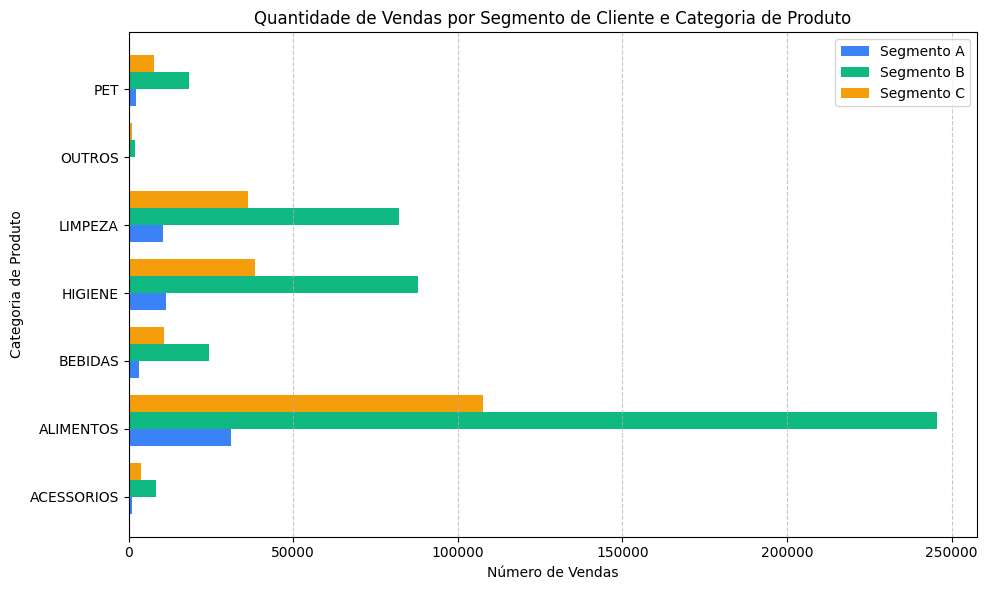

In [21]:
# Apresenta um gráfico de barras horizontais para a quantidade de vendas por segmento de cliente e categoria de produto usando a coluna PR_CAT no eixo x.
fig, ax = plt.subplots(figsize=(10, 6)) 

# Definindo cores para os três segmentos econômicos
cores_segmentos = ['#3b82f6', '#10b981', '#f59e0b']

# As categorias de produto serão os rótulos do eixo Y
categories = pivot_vendas_segmento_categoria['PR_CAT']
# Posições no eixo Y para cada grupo de barras
y_pos = np.arange(len(categories))

# Largura de cada barra individual
bar_height = 0.25

# Plotar as barras para o segmento A
ax.barh(y_pos - bar_height/2, pivot_vendas_segmento_categoria['A'], bar_height, label='Segmento A', color=cores_segmentos[0])

# Plotar as barras para o segmento B
ax.barh(y_pos + bar_height/2, pivot_vendas_segmento_categoria['B'], bar_height, label='Segmento B', color=cores_segmentos[1])

# Plotar as barras para o segmento C
ax.barh(y_pos + bar_height/2*3, pivot_vendas_segmento_categoria['C'], bar_height, label='Segmento C', color=cores_segmentos[2])

# Configurações do gráfico
ax.set_yticks(y_pos) # Define as posições dos ticks no eixo Y
ax.set_yticklabels(categories) # Define os rótulos dos ticks no eixo Y com as categorias
ax.set_xlabel('Número de Vendas')
ax.set_ylabel('Categoria de Produto')
ax.set_title('Quantidade de Vendas por Segmento de Cliente e Categoria de Produto')
ax.legend() # Mostra a legenda para identificar os segmentos
ax.grid(axis='x', linestyle='--', alpha=0.7) # Adiciona linhas de grade no eixo X para facilitar a leitura

plt.tight_layout() # Ajusta o layout para evitar sobreposição de elementos
plt.show()


In [22]:
# Categorias de Produtos mais comprados por Estado Civil de Cliente
categorias_mais_compradas_por_estado_civil = (
    df.groupby(['PR_CAT','ESTADO_CIVIL'])['CO_ID']
    .count()
    .reset_index()
    .rename(columns={'CO_ID': 'Quantidade Total de Vendas', 'ESTADO_CIVIL': 'Estado Civil', 'PR_CAT': 'Categoria'})
    .sort_values(by='Quantidade Total de Vendas', ascending=False)
    )
print("\nCategorias de Produtos mais comprados por estado civil (top 10):\n")
print(categorias_mais_compradas_por_estado_civil.head(10).reset_index(drop=True).to_string(formatters={'Quantidade Total de Vendas': '{:,}'.format}))   

# Pivot table para analisar a quantidade de vendas por estado civil e categoria de produto
pivot_vendas_estado_civil_categoria = (
    df.pivot_table(
        index='PR_CAT',
        columns='ESTADO_CIVIL',
        values='CO_ID',
        aggfunc='count',
        fill_value=0
    )
    .reset_index()
    .rename(columns={'ESTADO_CIVIL': 'Estado Civil'})
    )
print("\nQuantidade de vendas por estado civil e categoria de produto:\n")
print(
    pivot_vendas_estado_civil_categoria
    .reset_index(drop=True)
    .to_string(formatters={col: '{:}'
        .format for col in pivot_vendas_estado_civil_categoria.columns if col != 'Estado Civil'})
    )



Categorias de Produtos mais comprados por estado civil (top 10):

   Categoria          Estado Civil Quantidade Total de Vendas
0  ALIMENTOS              Separado                     98,817
1  ALIMENTOS              Solteiro                     93,872
2  ALIMENTOS            Divorciado                     90,379
3  ALIMENTOS  Casado/União Estável                     90,143
4    HIGIENE              Separado                     35,615
5    HIGIENE              Solteiro                     33,770
6    LIMPEZA              Separado                     33,218
7    HIGIENE  Casado/União Estável                     32,287
8    HIGIENE            Divorciado                     32,172
9    LIMPEZA              Solteiro                     31,509

Quantidade de vendas por estado civil e categoria de produto:

ESTADO_CIVIL      PR_CAT Casado/União Estável Divorciado Separado Solteiro Viúvo
0             ACESSORIOS                 2993       3006     3411     3115   346
1              ALIMENTOS 

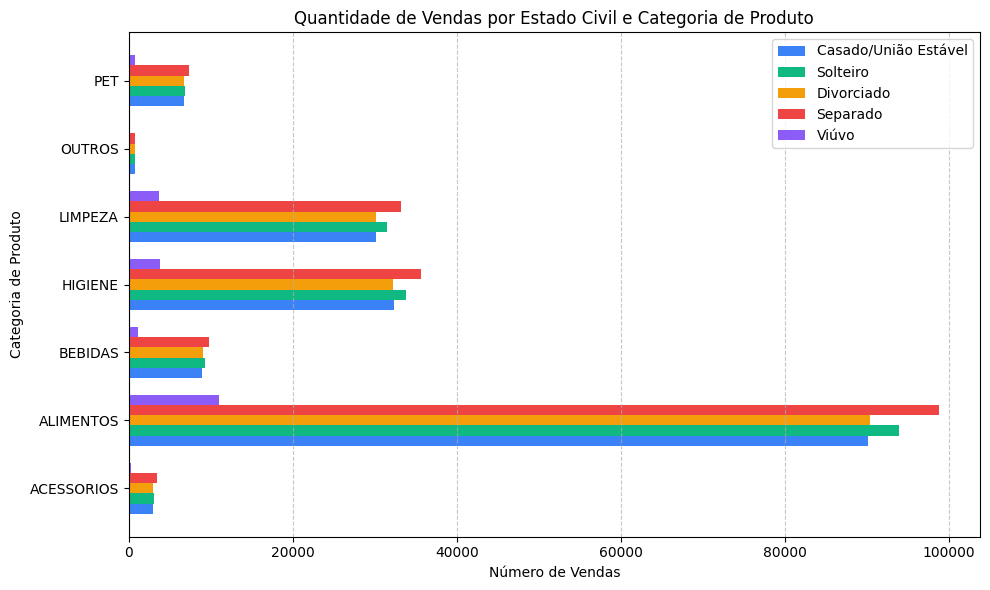

In [23]:
# Apresenta um gráfico de barras horizontais para a quantidade de vendas por estado civil e categoria de produto usando a coluna PR_CAT no eixo x.
fig, ax = plt.subplots(figsize=(10, 6)) 

# Definindo cores para os cinco estados civis
cores_segmentos = ['#3b82f6', '#10b981', '#f59e0b', '#ef4444', '#8b5cf6']

# As categorias de produto serão os rótulos do eixo Y
categories = pivot_vendas_estado_civil_categoria['PR_CAT']
# Posições no eixo Y para cada grupo de barras
y_pos = np.arange(len(categories))

# Largura de cada barra individual
bar_height = 0.15
num_estados_civis = 5
initial_offset = - (num_estados_civis - 1) / 2 * bar_height
ax.barh(y_pos + initial_offset,
        pivot_vendas_estado_civil_categoria['Casado/União Estável'],
        bar_height,
        label='Casado/União Estável',
        color=cores_segmentos[0])

ax.barh(y_pos + initial_offset + bar_height,
        pivot_vendas_estado_civil_categoria['Solteiro'],
        bar_height,
        label='Solteiro',
        color=cores_segmentos[1])

ax.barh(y_pos + initial_offset + 2 * bar_height,
        pivot_vendas_estado_civil_categoria['Divorciado'],
        bar_height,
        label='Divorciado',
        color=cores_segmentos[2])

ax.barh(y_pos + initial_offset + 3 * bar_height,
        pivot_vendas_estado_civil_categoria['Separado'],
        bar_height,
        label='Separado',
        color=cores_segmentos[3])

ax.barh(y_pos + initial_offset + 4 * bar_height,
        pivot_vendas_estado_civil_categoria['Viúvo'],
        bar_height,
        label='Viúvo',
        color=cores_segmentos[4])

# Configurações do gráfico
ax.set_yticks(y_pos) # Define as posições dos ticks no eixo Y
ax.set_yticklabels(categories) # Define os rótulos dos ticks no eixo Y com as categorias
ax.set_xlabel('Número de Vendas')
ax.set_ylabel('Categoria de Produto')
ax.set_title('Quantidade de Vendas por Estado Civil e Categoria de Produto')
ax.legend() # Mostra a legenda para identificar os segmentos
ax.grid(axis='x', linestyle='--', alpha=0.7) # Adiciona linhas de grade no eixo X para facilitar a leitura

plt.tight_layout() # Ajusta o layout para evitar sobreposição de elementos
plt.show()


### Passo 6 - Conclusões

**Conclusões das Análises de Vendas**

A análise exploratória dos dados de vendas oferece insights valiosos sobre o perfil dos clientes e seus padrões de consumo.

- **Vendas por Gênero:**
  
  - O volume de compras é ligeiramente dominado pelo gênero feminino, que registrou 432.576 transações, em comparação com 397.424 transações realizadas pelo gênero masculino. Essa diferença, embora não seja drástica, indica uma maior participação feminina no total de vendas.
- **Vendas por Categoria de Produto:**
  
  - A categoria "ALIMENTOS" é, de longe, a mais vendida, com 384.197 registros, evidenciando sua importância central no mix de produtos. As categorias "HIGIENE" (137.702 vendas) e "LIMPEZA" (128.632 vendas) também representam volumes significativos. Categorias como "BEBIDAS", "PET", "ACESSORIOS" e "OUTROS" têm menor representatividade. A presença de uma categoria "OUTROS" aponta para a necessidade de um tratamento contínuo de dados inconsistentes.
- **Vendas por Segmentação Econômica do Cliente:**
  
  - O segmento econômico 'B' é o principal motor do volume de transações, concentrando a maior parte das compras. Isso sugere que este grupo demográfico é o mais relevante para o negócio em termos de quantidade de vendas.
- **Vendas por Estado Civil do Cliente:**
  
  - A análise da pivot table que cruza categorias de produto com o estado civil do cliente (`PR_CAT` vs `Estado_Civil`) permite identificar padrões de consumo específicos. A análise indica que o estado civil influencia marginalmente quantidade de compras com ligeiro acréscimo entre os "Separados".
  
- **Vendas por Categorias de Produtos por Gênero:**
  
  - **Gênero Feminino (F):** "ALIMENTOS" é a categoria mais comprada (200.274 vendas), seguida por "HIGIENE" (71.721) e "LIMPEZA" (67.328).
  - **Gênero Masculino (M):** O padrão é similar, com "ALIMENTOS" liderando (183.923 vendas), seguido por "HIGIENE" (65.981) e "LIMPEZA" (61.304).
  - Em todas as categorias de produtos, o volume de vendas do gênero feminino é consistentemente maior ou muito próximo ao do gênero masculino, reforçando a maior participação feminina no total de transações.
- **Vendas por Categorias de Produtos por Segmentação Econômica do Cliente:**
  
  - **Classe A:** "ALIMENTOS" (31.118) é a categoria mais vendida, seguida por "HIGIENE" (11.326) e "LIMPEZA" (10.460).
  - **Classe B:** "ALIMENTOS" domina amplamente (245.501), com "HIGIENE" (87.943) e "LIMPEZA" (82.063) como as próximas categorias mais relevantes.
  - **Classe C:** "ALIMENTOS" também é a principal (107.578), seguida por "HIGIENE" (38.433) e "LIMPEZA" (36.109).
  - A categoria "ALIMENTOS" é a mais vendida em todas as classes econômicas, e as categorias de "HIGIENE" e "LIMPEZA" mantêm-se consistentemente como as próximas mais relevantes, indicando uma demanda universal por esses tipos de produtos, independentemente da segmentação econômica.
- **Vendas por Categorias de Produtos por Estado Civil do Cliente:**
  
  - **Casado/União Estável:** "ALIMENTOS" (90.143) é a principal, seguida por "HIGIENE" (32.287) e "LIMPEZA" (30.088).
  - **Divorciado:** "ALIMENTOS" (90.379) também lidera, com "HIGIENE" (32.172) e "LIMPEZA" (30.121) em seguida.
  - **Separado:** "ALIMENTOS" (98.817) é a mais vendida, seguida por "HIGIENE" (35.615) e "LIMPEZA" (33.218).
  - **Solteiro:** "ALIMENTOS" (93.872) é a principal, com "HIGIENE" (33.770) e "LIMPEZA" (31.509) em seguida.
  - **Viúvo:** "ALIMENTOS" (10.986) é a mais vendida, seguida por "HIGIENE" (3.858) e "LIMPEZA" (3.696).
  - O padrão de consumo por categoria de produto é notavelmente consistente entre os diferentes estados civis, com "ALIMENTOS", "HIGIENE" e "LIMPEZA" sendo as categorias de maior volume em todos os grupos. O grupo "Separado" demonstra um volume ligeiramente superior em "ALIMENTOS" e "HIGIENE" em comparação com os outros estados civis de maior volume.